In [1]:
#dataset = https://www.kaggle.com/datasets/wasiqaliyasir/breast-cancer-dataset

#importing libraries:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [3]:
#downloading dataset:
kagglehub.dataset_download('wasiqaliyasir/breast-cancer-dataset')

100%|██████████| 48.7k/48.7k [00:00<00:00, 348kB/s]

Extracting files...


'C:\\Users\\Lenovo\\.cache\\kagglehub\\datasets\\wasiqaliyasir\\breast-cancer-dataset\\versions\\1'

In [2]:
#importing dataset:
df = pd.read_csv(r'C:\\Users\\Lenovo\\.cache\\kagglehub\\datasets\\wasiqaliyasir\\breast-cancer-dataset\\versions\\1\Breast_cancer_dataset.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
#fixing datset:
df.drop(columns = ['id', 'Unnamed: 32'], inplace = True)
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

In [4]:
#defining features and target:
x = df.drop(columns = ['diagnosis'])
y = df['diagnosis']

In [5]:
#splitting data for training and testing:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [6]:
#creating ai model:
model = LogisticRegression(max_iter = 5000, class_weight = 'balanced')

In [7]:
#training ai model:
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [8]:
#testing ai model based on testing data:
predictions = model.predict(x_test)

In [9]:
#evaluating ai model:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       108
           1       0.95      0.97      0.96        63

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



In [10]:
confusion_matrix(y_test, predictions)

array([[105,   3],
       [  2,  61]])

In [16]:
#custom prediction:
model.predict(pd.DataFrame(data = [[
    12.0, 14.5, 78.0, 450.0, 0.085, 0.06, 0.03, 0.02, 0.18, 0.060,
    0.25, 0.90, 1.80, 17.0, 0.006, 0.020, 0.020, 0.010, 0.015, 0.002,
    13.0, 16.0, 85.0, 520.0, 0.095, 0.12, 0.10, 0.05, 0.20, 0.07
]], columns = x.columns))

array([0])

<Axes: >

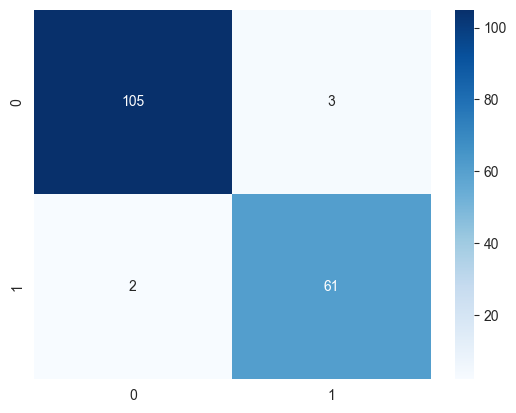

In [23]:
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, cmap = 'Blues', fmt = 'd')